# FM-03 — Sparse FM seed 42 공통-fold 스크리닝

## 목표
동일한 seed 42 Stratified 5-fold에서 Sparse FM optimizer·rank·class weight 후보를 압축한다. 이 파일은 개발용 스크리닝이며, 최종 채택은 상위 후보만 별도 3-seed로 검증한다.

- O0: sklearn LR 재현 및 PyTorch Linear(상호작용 제거) 점검
- O1: rank=8, learning rate `3e-4 / 1e-3 / 3e-3`
- O2: O1 승자 learning rate, rank `4 / 8 / 16`
- O3: O1~O2 승자, class weight `balanced / sqrt-balanced / none`
- 모든 후보: 08-spec LR + FM `0.25 / 0.50` 고정 blend와 paired delta 저장

### 고정 안전 규칙
train.csv만 읽고, test는 token·통계·스케일·후보 선택에 사용하지 않는다. 모든 outer fold는 fold-train만으로 token·numeric scale·inner early stopping을 구성한다. NaN은 mutation event가 아니다.


In [1]:
from pathlib import Path
import subprocess, sys, json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def find_exp_model():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'fm_screen_runner.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'exp_model' / 'common' / 'fm_screen_runner.py'
        if direct.exists():
            return path
        if project.exists():
            return project.parent.parent
    raise FileNotFoundError('FM-03 runner를 찾지 못했습니다.')

EXP_MODEL = find_exp_model()
RUNNER = EXP_MODEL / 'common' / 'fm_screen_runner.py'
RESULT_DIR = EXP_MODEL / 'result'
RUN_ID = 'FM-03'
SCREEN_SEED = 42
RUN_EXPERIMENT = True
print({'runner': RUNNER, 'seed': SCREEN_SEED, 'run_id': RUN_ID})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/common/fm_screen_runner.py'), 'seed': 42, 'run_id': 'FM-03'}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--seed', str(SCREEN_SEED), '--run-id', RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    assert process.stdout is not None
    tail = []
    for line in process.stdout:
        print(line, end='')
        tail = (tail + [line])[-80:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f'FM-03 runner failed (exit={return_code}). Last runner output:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과 집계만 수행합니다.')



row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 392.28it/s]

FM-03 shared folds: 100%|██████████| 5/5 [00:02<00:00,  1.80it/s]

O0 sklearn LR: 100%|██████████| 5/5 [00:28<00:00,  5.76s/fold]

O0_torch_linear: 100%|██████████| 5/5 [01:59<00:00, 23.87s/fold]

O1_lr_0.0003: 100%|██████████| 5/5 [05:08<00:00, 61.60s/fold]

O1_lr_0.001: 100%|██████████| 5/5 [02:56<00:00, 35.37s/fold]

O1_lr_0.003: 100%|██████████| 5/5 [02:35<00:00, 31.05s/fold]

O2_rank_4: 100%|██████████| 5/5 [03:19<00:00, 39.87s/fold]

O2_rank_8: 100%|██████████| 5/5 [04:42<00:00, 56.44s/fold]

O2_rank_16: 100%|██████████| 5/5 [08:37<00:00, 103.57s/fold]

O3_weight_balanced: 100%|██████████| 5/5 [04:39<00:00, 55.90s/fold]

O3_weight_sqrt_balanced: 100%|██████████| 5/5 [04:32<00:00, 54.46s/fold]

O3_weight_none: 100%|██████████| 5/5 [04:46<00:00, 57.31s/fold]
{
  "O1_learning_rate": {
    "candidate_id": "O1_lr_0.0003",
    "kind": "fm",
    "rank": 8,
    "learning_rate": 0.0003,
    "class_weight": "b

,candidate_id,kind,rank,learning_rate,class_weight,seed,baseline_oof_macro_f1,fm_oof_macro_f1,blend_0p25_oof_macro_f1,blend_0p50_oof_macro_f1,paired_delta_0p25_oof,paired_delta_0p50_oof,paired_delta_0p25_fold_mean,paired_delta_0p25_fold_min,early_stopping_epoch_mean,loss_finite,runtime_seconds,feature_count_mean,leakage_check,nan_as_mutation_count
2,O1_lr_0.0003,fm,8,0.0003,balanced,42,0.482593,0.351593,0.486993,0.454991,0.004400,-0.027602,0.004790,0.000201,5.0,True,308.048290,14496.0,True,0
6,O2_rank_8,fm,8,0.0003,balanced,42,0.482593,0.351593,0.486993,0.455117,0.004400,-0.027476,0.004790,0.000201,5.0,True,282.257585,14496.0,True,0
8,O3_weight_balanced,fm,8,0.0003,balanced,42,0.482593,0.351593,0.486993,0.454991,0.004400,-0.027602,0.004790,0.000201,5.0,True,279.511276,14496.0,True,0
9,O3_weight_sqrt_balanced,fm,8,0.0003,sqrt_balanced,42,0.482593,0.330693,0.485909,0.446556,0.003316,-0.036036,0.002833,-0.000632,4.8,True,272.353097,14496.0,True,0
3,O1_lr_0.001,fm,8,0.0010,balanced,42,0.482593,0.302568,0.483617,0.455187,0.001024,-0.027405,0.001845,-0.009955,1.6,True,176.866187,14496.0,True,0
7,O2_rank_16,fm,16,0.0003,balanced,42,0.482593,0.345303,0.482735,0.443231,0.000142,-0.039362,0.000024,-0.008191,4.4,True,517.873668,14496.0,True,0
0,O0_sklearn_lr,sklearn_lr,0,0.0000,balanced,42,0.482593,0.482593,0.482593,0.482593,0.000000,0.000000,0.000000,0.000000,NaN,True,NaN,8175.2,True,0
5,O2_rank_4,fm,4,0.0003,balanced,42,0.482593,0.327401,0.482377,0.446784,-0.000215,-0.035809,0.000286,-0.003979,6.6,True,199.381120,14496.0,True,0
1,O0_torch_linear,linear,0,0.0010,balanced,42,0.482593,0.382871,0.482067,0.466294,-0.000526,-0.016299,0.000313,-0.007405,16.8,True,117.284328,14496.0,True,0
10,O3_weight_none,fm,8,0.0003,none,42,0.482593,0.301663,0.481904,0.431000,-0.000688,-0.051593,-0.000617,-0.008708,5.2,True,286.608994,14496.0,True,0


,candidate_id,kind,rank,learning_rate,class_weight
O1_learning_rate,O1_lr_0.0003,fm,8,0.0003,balanced
O2_rank,O2_rank_8,fm,8,0.0003,balanced
screen_winner,O1_lr_0.0003,fm,8,0.0003,balanced


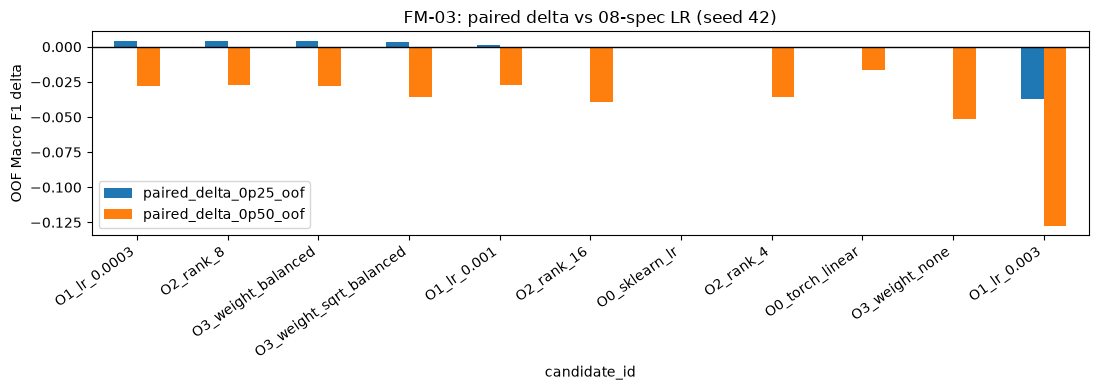

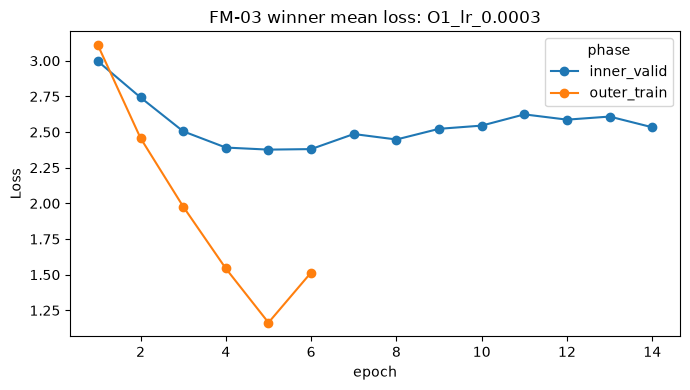

In [4]:
candidate_path = RESULT_DIR / f'{RUN_ID}_seed{SCREEN_SEED}_candidates.csv'
fold_path = RESULT_DIR / f'{RUN_ID}_seed{SCREEN_SEED}_folds.csv'
loss_path = RESULT_DIR / f'{RUN_ID}_seed{SCREEN_SEED}_loss.csv'
selection_path = RESULT_DIR / f'{RUN_ID}_seed{SCREEN_SEED}_selection.json'
for path in (candidate_path, fold_path, loss_path, selection_path):
    if not path.exists():
        raise FileNotFoundError(f'누락 결과: {path}')
candidates = pd.read_csv(candidate_path).sort_values(['paired_delta_0p25_oof', 'paired_delta_0p25_fold_min'], ascending=False)
folds = pd.read_csv(fold_path)
losses = pd.read_csv(loss_path)
selection = json.loads(selection_path.read_text(encoding='utf-8'))
assert candidates.leakage_check.all() and candidates.nan_as_mutation_count.eq(0).all() and candidates.loss_finite.all()
display(candidates)
display(pd.DataFrame(selection).T)

ax = candidates.plot.bar(x='candidate_id', y=['paired_delta_0p25_oof', 'paired_delta_0p50_oof'], figsize=(11, 4), title='FM-03: paired delta vs 08-spec LR (seed 42)')
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('OOF Macro F1 delta')
plt.xticks(rotation=35, ha='right'); plt.tight_layout()
plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SCREEN_SEED}_paired_delta.png', dpi=160)
plt.show()

winner_id = selection['screen_winner']['candidate_id']
winner_loss = losses[losses.candidate_id.eq(winner_id)]
ax = winner_loss.pivot_table(
    index='epoch',
    columns='phase',
    values='loss',
    aggfunc='mean',
).plot(marker='o', figsize=(7, 4), title=f'FM-03 winner mean loss: {winner_id}')
ax.set_ylabel('Loss'); plt.tight_layout()
plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SCREEN_SEED}_winner_loss.png', dpi=160)
plt.show()
